
Iteration Details:
Step 0 --> x = 18.0000, f(x) = 7.0000

Step 1:
Current x = 18.0000, f(x) = 7.0000
Left Neighbour x = 17.4000, f(x) = 17.4400
Right Neighbour x = 18.6000, f(x) = -4.1600
Moving Left

Step 2:
Current x = 17.4000, f(x) = 17.4400
Left Neighbour x = 16.8000, f(x) = 27.1600
Right Neighbour x = 18.0000, f(x) = 7.0000
Moving Left

Step 3:
Current x = 16.8000, f(x) = 27.1600
Left Neighbour x = 16.2000, f(x) = 36.1600
Right Neighbour x = 17.4000, f(x) = 17.4400
Moving Left

Step 4:
Current x = 16.2000, f(x) = 36.1600
Left Neighbour x = 15.6000, f(x) = 44.4400
Right Neighbour x = 16.8000, f(x) = 27.1600
Moving Left

Step 5:
Current x = 15.6000, f(x) = 44.4400
Left Neighbour x = 15.0000, f(x) = 52.0000
Right Neighbour x = 16.2000, f(x) = 36.1600
Moving Left

Step 6:
Current x = 15.0000, f(x) = 52.0000
Left Neighbour x = 14.4000, f(x) = 58.8400
Right Neighbour x = 15.6000, f(x) = 44.4400
Moving Left

Step 7:
Current x = 14.4000, f(x) = 58.8400
Left Neighbour x = 13.8000, f(x) = 

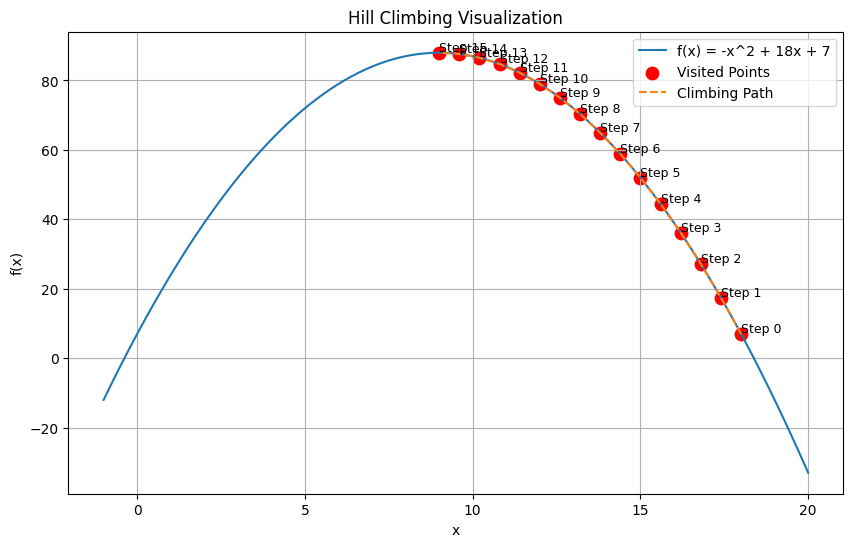

In [1]:
import matplotlib.pyplot as plt
import numpy as np


def obj_func(x):
    return -(x**2) + 18*x + 7


def hill_climbing(start, step_size, max_iter):   # Corrected: step_size instead of stepsize
    cur = start
    cur_val = obj_func(cur)                      # Corrected: better variable naming
    path = [(cur, cur_val)]

    print("\nIteration Details:")
    print(f"Step 0 --> x = {cur:.4f}, f(x) = {cur_val:.4f}")
    # Corrected: removed extra 0 and fixed formatting

    for i in range(1, max_iter + 1):            # Corrected: include max_iter properly
        left_nbr = cur - step_size
        right_nbr = cur + step_size

        left_val = obj_func(left_nbr)
        right_val = obj_func(right_nbr)

        print(f"\nStep {i}:")
        print(f"Current x = {cur:.4f}, f(x) = {cur_val:.4f}")
        print(f"Left Neighbour x = {left_nbr:.4f}, f(x) = {left_val:.4f}")
        print(f"Right Neighbour x = {right_nbr:.4f}, f(x) = {right_val:.4f}")

        if left_val > cur_val and left_val >= right_val:
            cur = left_nbr
            cur_val = left_val
            print("Moving Left")

        elif right_val > cur_val and right_val >= left_val:
            # Corrected: used right_val >= left_val for consistency
            cur = right_nbr
            cur_val = right_val
            print("Moving Right")

        else:
            print("Local maxima reached")
            break

        path.append((cur, cur_val))

    return cur, cur_val, path


start = float(input("Enter the starting point: "))
step_size = float(input("Enter the step size: "))
max_iter = int(input("Enter the maximum iterations: "))

best_sol, best_val, path = hill_climbing(start, step_size, max_iter)

print("\nBest Solution Found:", best_sol)
print(f"Maximum value = {best_val:.4f}")

# Corrected: increased number of points for smoother graph
x = np.linspace(-1, 20, 500)
y = obj_func(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label="f(x) = -x^2 + 18x + 7")

path_x = [p[0] for p in path]
path_y = [p[1] for p in path]

plt.scatter(path_x, path_y, color="red", s=80, label="Visited Points")
plt.plot(path_x, path_y, linestyle="--", label="Climbing Path")
# Corrected: added dashed line for better visibility

for i, (px, py) in enumerate(path):
    plt.text(px, py + 0.5, f"Step {i}", fontsize=9)

plt.title("Hill Climbing Visualization")
# Corrected: fixed spelling of Visualization

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()


In [18]:
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
from sklearn.naive_bayes import GaussianNB

df=pd.read_csv("iris_dataset.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [7]:
X=df.drop(columns=["target"],axis=1)
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [9]:
y=df["target"]
y.head()

0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: target, dtype: object

In [10]:
#Train test split of 90-10
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=42)

In [15]:
#Train test split of 70-30
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [16]:
#Training a Gaussian Naive Bayes ML Model
model_gb=GaussianNB()
model_gb.fit(X_train,y_train)


GaussianNB()

In [ ]:
#Test/Prediction
y_pred=model_gb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9777777777777777
